Sentinel Hub is a hosted service running on the cloud alongside the data. This should make access faster and is especially useful when using it to do computations.

Compared to openEO, the interface is also not standardized. Meaning that the transferability of methods to use Sentinel Hub is limited. It uses evalscripts which are defined as javascript, and while there are good resources to learn how to build evalscripts, the learning curve shouldn't be neglected.

We are using the sentinelhub-py package which provides wrappers around the Sentinel Hub APIs.

In [1]:
import pickle
import datetime
from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    MimeType,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    SHConfig,
)
import pystac_client
import matplotlib.pyplot as plt

/home/jonas/Documents/Projects/2026/s2-time-series-access/sh-nb/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)

bbox_sh = BBox(p["box_3035"].bounds, CRS(3035))

## Light wrapper

The first access pattern downloads many separate GeoTiffs, since Sentinel Hub does not provide a native way to export zarrs. 

The download follows [the example](https://sentinelhub-py.readthedocs.io/en/latest/examples/process_request_cdse.html#Example-8-:-Multiple-timestamps-data) from the docs on how to download many requests at once.

In [3]:
config = SHConfig("free-cdse")

URL = "https://stac.dataspace.copernicus.eu/v1"
cat = pystac_client.Client.open(URL)
cat.add_conforms_to("ITEM_SEARCH")

In [4]:
%%time
params = {
    "limit": 100,
    "collections": "sentinel-2-l2a",
    "datetime": f"{p['start'].strftime('%Y-%m-%d')}/{p['end'].strftime('%Y-%m-%d')}",
    "bbox": p["box_4326"].bounds,
    "query": {"eo:cloud_cover": {"lte": 80}},
    "sortby": "properties.eo:cloud_cover",
    "fields": {"exclude": ["geometry"]},
}
stac_items = list(cat.search(**params).item_collection())

CPU times: user 350 ms, sys: 62.2 ms, total: 412 ms
Wall time: 3.05 s


This is the hard part when using Sentinel Hub: Defining an evalscript which works. While all other solutions in Python provide a single parameter to specify which bands should be fetched, the basic Sentinel Hub API and Python package does not offer any help in that regard.

In [5]:
evalscript_single_band = """//VERSION=3

bands = ["B03", "B11", "SCL"]

function setup() {
    return {
        input: [{
                bands: bands,
                units: "DN"
            }],
        output: {
            bands: bands.length,
            sampleType: "UINT16"

        },
        mosaicking: "SIMPLE"
    }
}

function evaluatePixel(samples) {
    return bands.map(band => samples[band]);
}
"""

We then define a function which takes in a time-interval and builds a Sentinel Hub API request.
This function is then applied to all items which we queried from the STAC catalog, to get a single request per acquisition.

In [6]:
def get_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_single_band,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A.define_from(
                    "s2", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox_sh,
        resolution=(10, 10),
        config=config,
        data_folder="./data",
    )

In [7]:
acquisitions_dates = [
    datetime.datetime.fromisoformat(stac_item.properties["datetime"]).strftime(
        "%Y-%m-%d"
    )
    for stac_item in stac_items
]
requests = [get_request((date, date)) for date in acquisitions_dates]

For free users, Sentinel Hub allows [300 requests](https://documentation.dataspace.copernicus.eu/Quotas.html) per minute. But also will limit when [sending requests in quick bursts](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/RateLimiting.html).

When we can only control the number of threads this is difficult to set. However since we only want to get 89 acquisitions and every acquisitions only needs a single request, we can set a pretty high number of threads before we run into issues. And once we hit the burst limit, the Sentinel Hub client will retry those requests.

In [9]:
%%time
list_of_requests = [request.download_list[0] for request in requests]

# download data with multiple threads
data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=32
)

/home/jonas/Documents/Projects/2026/s2-time-series-access/sh-nb/.venv/lib/python3.13/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)
/home/jonas/Documents/Projects/2026/s2-time-series-access/sh-nb/.venv/lib/python3.13/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)
/home/jonas/Documents/Projects/2026/s2-time-series-access/sh-nb/.venv/lib/python3.13/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)
/home/jonas/Documents/Projects/2026/s2-time-series-access/sh-nb/.venv/lib/python3.13/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Downloa

CPU times: user 9.31 s, sys: 2.11 s, total: 11.4 s
Wall time: 28.2 s


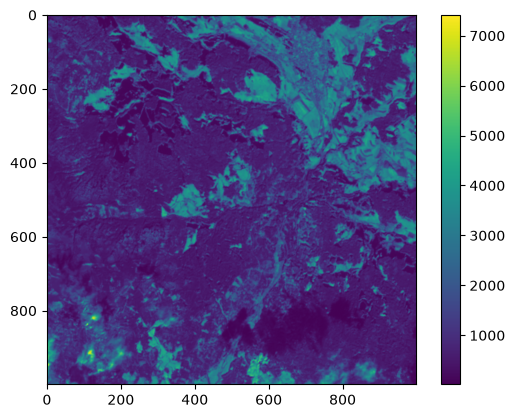

In [10]:
plt.imshow(data[22][:, :, 1])
plt.colorbar();

We indeed hit the rate limit, but still it completed all requests within 30 seconds.

# Lazy datacube via `sh_datacube.load`

As an experiment to make the Sentinel Hub APIs more convenient for this specific use-case of getting a lot of data quickly as a zarr, I implemented a utility to construct a dask lazy dataarray which gets populated by requests to Sentinel Hub.

This is presented here.

In [11]:
from sh_datacube import load

cube = load(
    DataCollection.SENTINEL2_L2A,
    bands=["B03", "B11", "SCL"],
    bbox=bbox_sh,  # BBox in EPSG:3035 from the params above
    time=(p["start"].strftime("%Y-%m-%d"), p["end"].strftime("%Y-%m-%d")),
    resolution=10,
    filter="eo:cloud_cover < 80",
    config=config,
).to_dataset(dim="band")
# lazy: nothing downloaded yet, one request per timestamp

In [14]:
%%time
computed = cube.compute(scheduler="threads", num_workers=8)

CPU times: user 6.56 s, sys: 2.42 s, total: 8.97 s
Wall time: 23.8 s


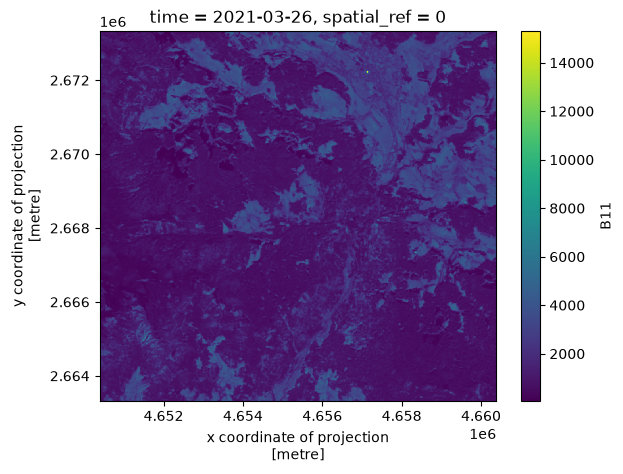

In [13]:
computed.B11.isel(time=22).plot();